In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate


In [ ]:
# Load coordinate and curvature data
x, y =   np.loadtxt('GMZ/down/RuO2-kslice-coord.dat', unpack=True)
zdown =  np.loadtxt('GMZ/down/RuO2-kslice-curv.dat', unpack=True)
zup =    np.loadtxt('GMZ/up/RuO2-kslice-curv.dat', unpack=True)

zmax = 200
zdown = np.where(zdown < zmax, zdown, 0)
zup = np.where(zup < zmax, zup, 0)
print(np.min(zdown), np.max(zdown))

# Calculate ranges for later use
x_range = x.max() - x.min()
y_range = y.max() - y.min()

# Define k-slice plane according to your specification:
# kslice_corner = 0.0 0.0 0.0        ! Gamma point (corner 1)
# kslice_b1 = 0.5 0.5 0.0            ! Direction to M point
# kslice_b2 = 0.0 0.0 0.5            ! Direction to A point (via Z)

# K-point coordinates in fractional coordinates
gamma_point = np.array([0.0, 0.0, 0.0])  # Γ point
M_point = np.array([0.5, 0.5, 0.0])      # M point  
A_point = np.array([0.0, 0.0, 0.5])      # A point

print(f"Data shape: x={len(x)}, y={len(y)}")
print(f"Berry curvature components: {len(zup)} (x, y, z components)")
print(f"X range: {x.min():.3f} to {x.max():.3f}")
print(f"Y range: {y.min():.3f} to {y.max():.3f}")
print(f"x_range = {x_range:.3f}, y_range = {y_range:.3f}")

-27.785131 171.49603
Data shape: x=9409, y=9409
Berry curvature components: 3 (x, y, z components)
X range: 0.000 to 0.979
Y range: 0.000 to 1.003
x_range = 0.979, y_range = 1.003


Global color range: min=-47.9823, max=171.4960
x-component range: min=-47.9823, max=90.6307
y-component range: min=-4.7821, max=89.4148
z-component range: min=-27.7851, max=171.4960


C:\Users\ASUS\AppData\Local\Temp\ipykernel_48688\1486466673.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


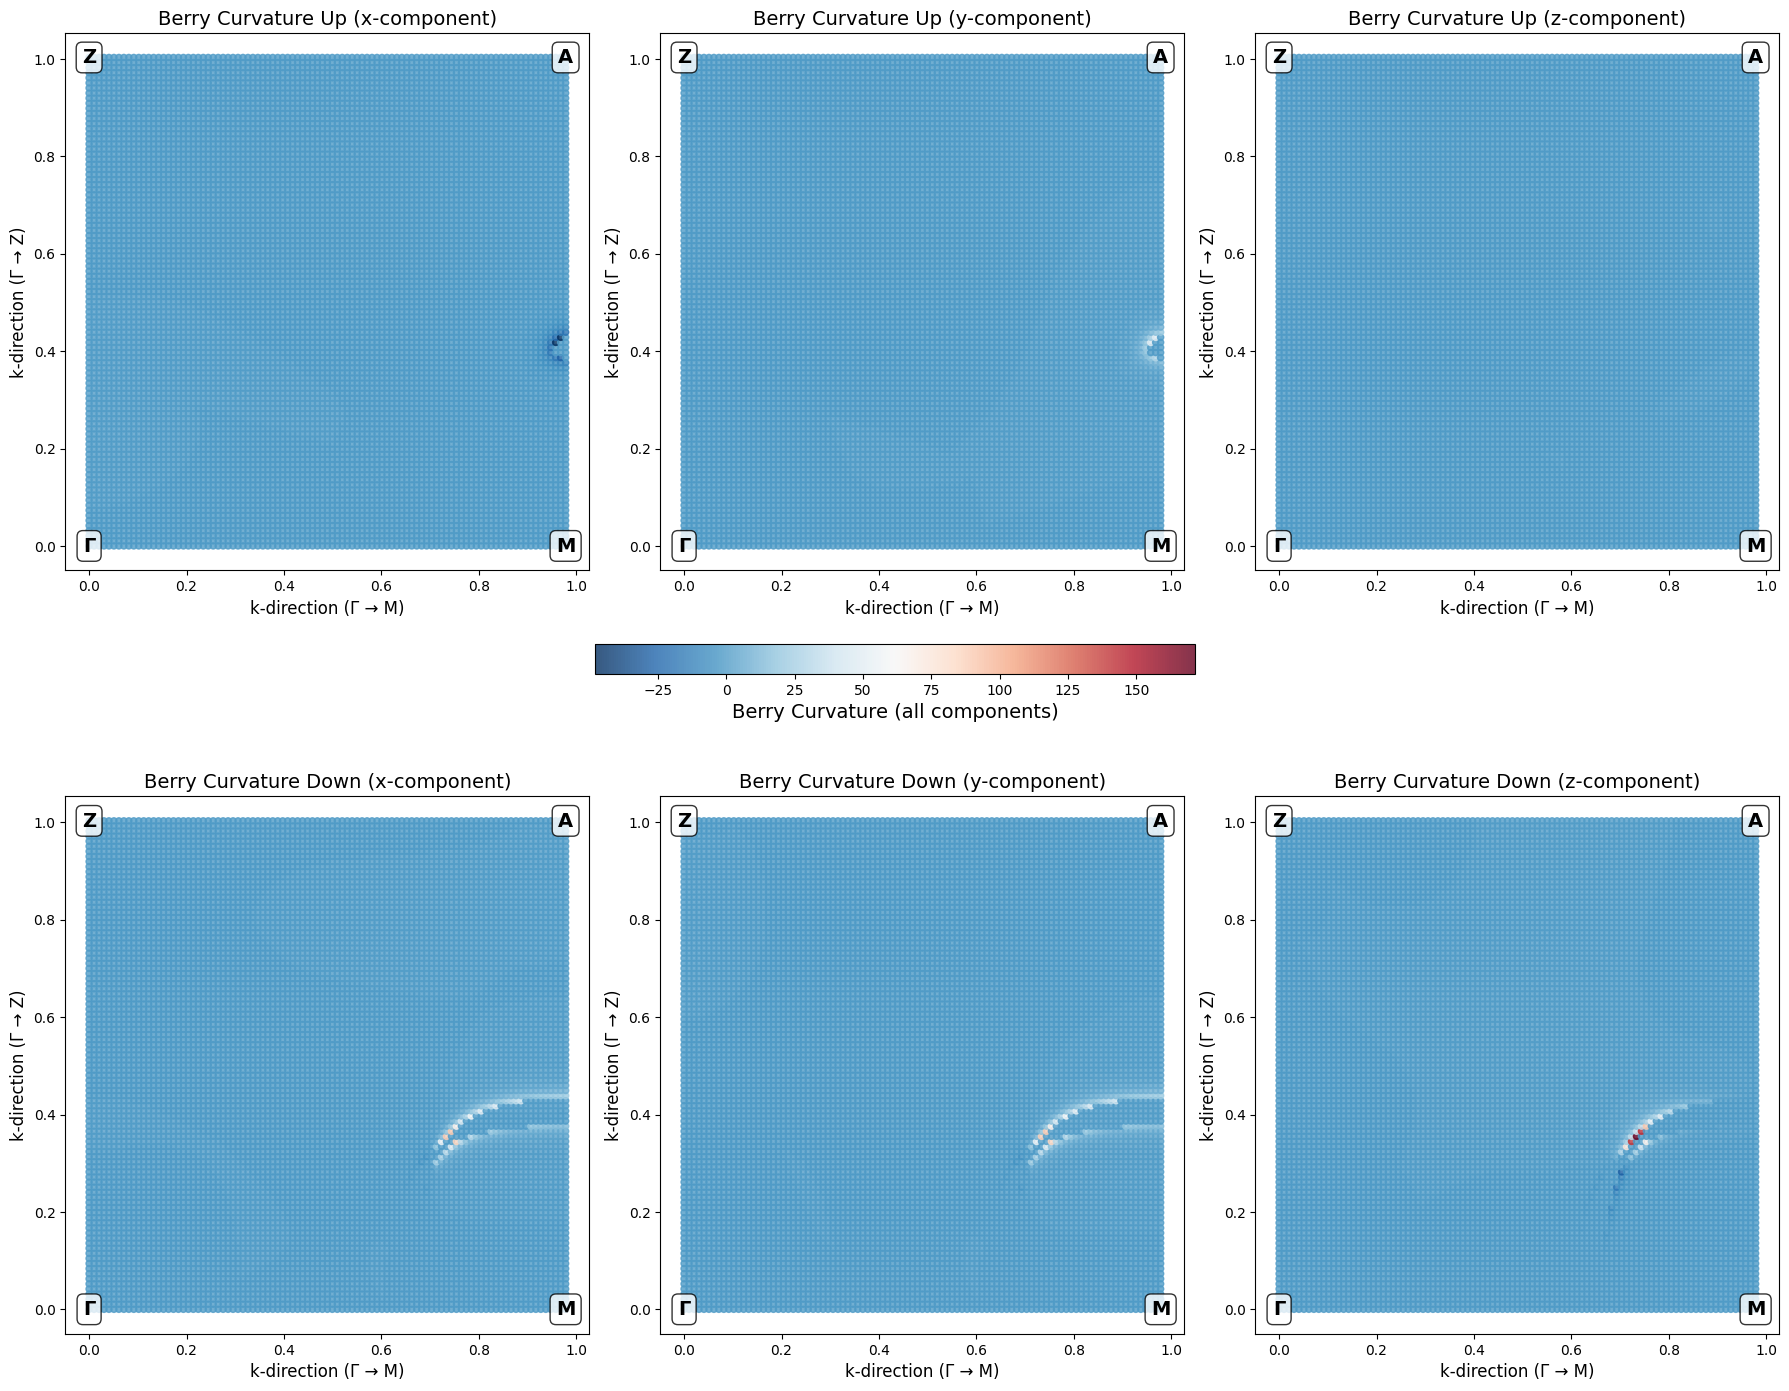

In [3]:
# Create figure with subplots for all three Berry curvature components
fig, axes = plt.subplots(2, 3, figsize=(18, 15))

# Component names
components = ['x', 'y', 'z']

# Calculate global color range for ALL components (shared across x, y, z)
vmin_global = min(np.min(zup[0]), np.min(zup[1]), np.min(zup[2]), 
                  np.min(zdown[0]), np.min(zdown[1]), np.min(zdown[2]))
vmax_global = max(np.max(zup[0]), np.max(zup[1]), np.max(zup[2]), 
                  np.max(zdown[0]), np.max(zdown[1]), np.max(zdown[2]))

print(f'Global color range: min={vmin_global:.4f}, max={vmax_global:.4f}')

# Store scatter plot for colorbar reference
scatter_ref = None

for i, comp_name in enumerate(components):
    # Print individual component ranges for reference
    vmin_comp = min(np.min(zup[i]), np.min(zdown[i]))
    vmax_comp = max(np.max(zup[i]), np.max(zdown[i]))
    print(f'{comp_name}-component range: min={vmin_comp:.4f}, max={vmax_comp:.4f}')
    
    # Plot for up component (top row) - using global color scale
    scatter_up = axes[0, i].scatter(x, y, c=zup[i], cmap='RdBu_r', s=20, alpha=0.8, 
                                    vmin=vmin_global, vmax=vmax_global)
    axes[0, i].set_xlabel('k-direction (Γ → M)', fontsize=12)
    axes[0, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[0, i].set_title(f'Berry Curvature Up ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[0, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.min(), 'M', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.max(), 'A', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[0, i].tick_params(labelsize=10)
    axes[0, i].set_aspect('equal')

    # Plot for down component (bottom row) - using global color scale
    scatter_down = axes[1, i].scatter(x, y, c=zdown[i], cmap='RdBu_r', s=20, alpha=0.8,
                                      vmin=vmin_global, vmax=vmax_global)
    axes[1, i].set_xlabel('k-direction (Γ → M)', fontsize=12)
    axes[1, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[1, i].set_title(f'Berry Curvature Down ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[1, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.min(), 'M', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.max(), 'A', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[1, i].tick_params(labelsize=10)
    axes[1, i].set_aspect('equal')
    
    # Store reference for shared colorbar
    if scatter_ref is None:
        scatter_ref = scatter_up

# Add single shared horizontal colorbar below all subplots
cbar = fig.colorbar(scatter_ref, ax=axes, orientation='horizontal', fraction=0.04, pad=0.08)
cbar.ax.set_position([0.25, 0.45, 0.5, 0.02])  # [left, bottom, width, height] in figure coordinates
cbar.set_label('Berry Curvature (all components)', fontsize=14)

plt.tight_layout()
plt.show()

In [4]:
# Load coordinate and curvature data
x, y =   np.loadtxt('GXZ/down/RuO2-kslice-coord.dat', unpack=True)
zdown =  np.loadtxt('GXZ/down/RuO2-kslice-curv.dat', unpack=True)
zup =    np.loadtxt('GXZ/up/RuO2-kslice-curv.dat', unpack=True)

zmax = 1e200
zdown = np.where(zdown < zmax, zdown, 0)
zup = np.where(zup < zmax, zup, 0)
print(np.min(zdown), np.max(zdown))

# Calculate ranges for later use
x_range = x.max() - x.min()
y_range = y.max() - y.min()

# Define k-slice plane according to your specification:
# kslice_corner = 0.0 0.0 0.0        ! Gamma point (corner 1)
# kslice_b1 = 0.5 0.5 0.0            ! Direction to M point
# kslice_b2 = 0.0 0.0 0.5            ! Direction to A point (via Z)

# K-point coordinates in fractional coordinates
gamma_point = np.array([0.0, 0.0, 0.0])  # Γ point
M_point = np.array([0.5, 0.5, 0.0])      # M point  
A_point = np.array([0.0, 0.0, 0.5])      # A point
print(max(zup[0]), max(zup[1]), max(zup[2]), max(zdown[0]), max(zdown[1]), max(zdown[2]))

-0.18831295 0.18082575
0.11114124 0.1973437 0.057638434 0.12122322 0.18082575 0.051764641


Global color range: min=-0.2152, max=0.1973
x-component range: min=-0.2149, max=0.1212
y-component range: min=-0.2152, max=0.1973
z-component range: min=-0.1296, max=0.0576


C:\Users\ASUS\AppData\Local\Temp\ipykernel_48688\1486466673.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


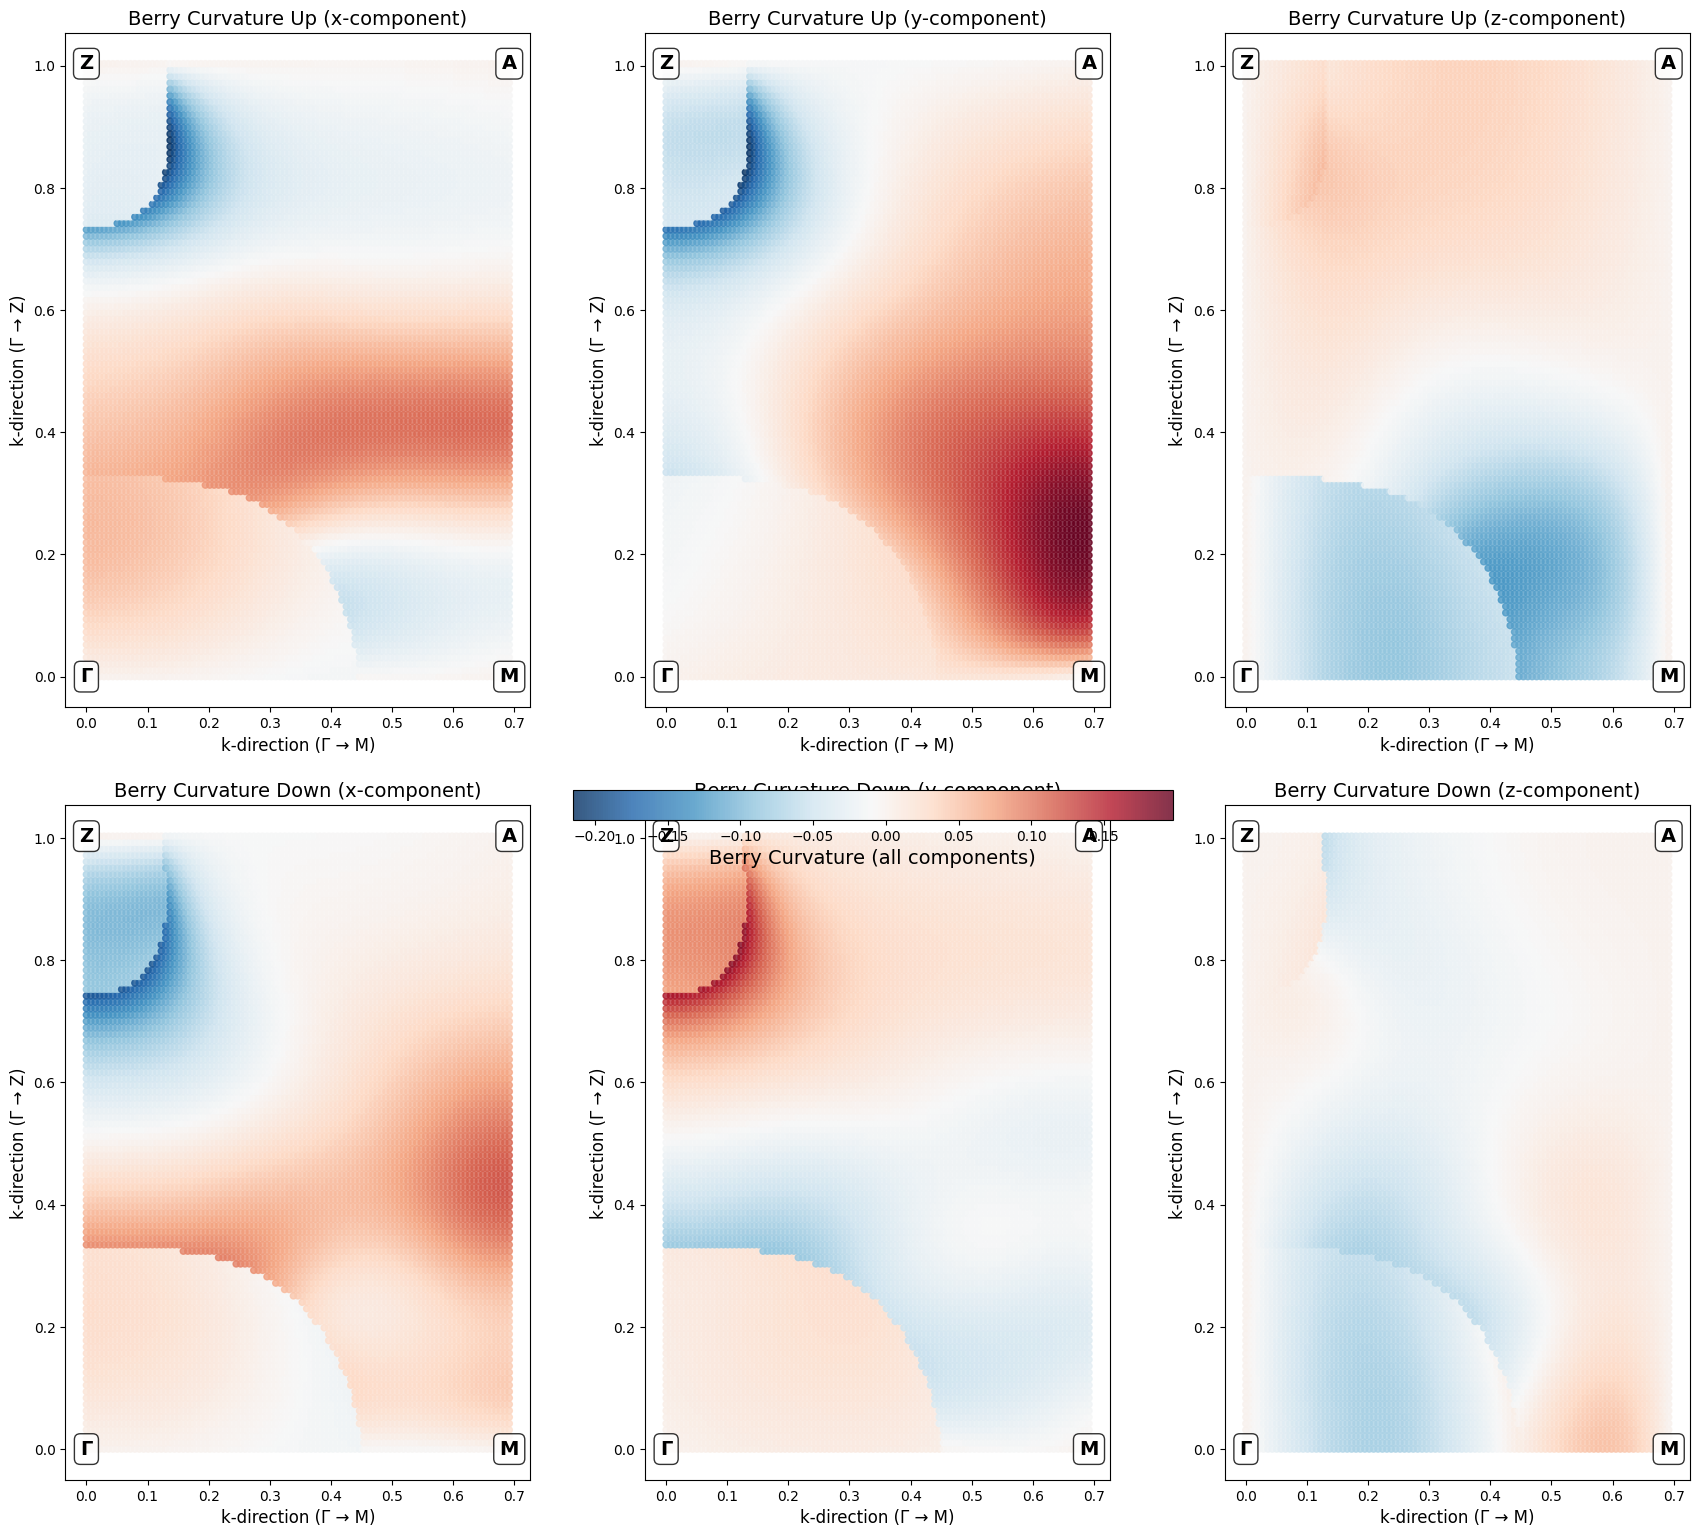

In [5]:
# Create figure with subplots for all three Berry curvature components
fig, axes = plt.subplots(2, 3, figsize=(18, 15))

# Component names
components = ['x', 'y', 'z']

# Calculate global color range for ALL components (shared across x, y, z)
vmin_global = min(np.min(zup[0]), np.min(zup[1]), np.min(zup[2]), 
                  np.min(zdown[0]), np.min(zdown[1]), np.min(zdown[2]))
vmax_global = max(np.max(zup[0]), np.max(zup[1]), np.max(zup[2]), 
                  np.max(zdown[0]), np.max(zdown[1]), np.max(zdown[2]))

print(f'Global color range: min={vmin_global:.4f}, max={vmax_global:.4f}')

# Store scatter plot for colorbar reference
scatter_ref = None

for i, comp_name in enumerate(components):
    # Print individual component ranges for reference
    vmin_comp = min(np.min(zup[i]), np.min(zdown[i]))
    vmax_comp = max(np.max(zup[i]), np.max(zdown[i]))
    print(f'{comp_name}-component range: min={vmin_comp:.4f}, max={vmax_comp:.4f}')
    
    # Plot for up component (top row) - using global color scale
    scatter_up = axes[0, i].scatter(x, y, c=zup[i], cmap='RdBu_r', s=20, alpha=0.8, 
                                    vmin=vmin_global, vmax=vmax_global)
    axes[0, i].set_xlabel('k-direction (Γ → M)', fontsize=12)
    axes[0, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[0, i].set_title(f'Berry Curvature Up ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[0, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.min(), 'M', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.max(), 'A', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[0, i].tick_params(labelsize=10)
    axes[0, i].set_aspect('equal')

    # Plot for down component (bottom row) - using global color scale
    scatter_down = axes[1, i].scatter(x, y, c=zdown[i], cmap='RdBu_r', s=20, alpha=0.8,
                                      vmin=vmin_global, vmax=vmax_global)
    axes[1, i].set_xlabel('k-direction (Γ → M)', fontsize=12)
    axes[1, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[1, i].set_title(f'Berry Curvature Down ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[1, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.min(), 'M', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.max(), 'A', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[1, i].tick_params(labelsize=10)
    axes[1, i].set_aspect('equal')
    
    # Store reference for shared colorbar
    if scatter_ref is None:
        scatter_ref = scatter_up

# Add single shared horizontal colorbar below all subplots
cbar = fig.colorbar(scatter_ref, ax=axes, orientation='horizontal', fraction=0.04, pad=0.08)
cbar.ax.set_position([0.25, 0.45, 0.5, 0.02])  # [left, bottom, width, height] in figure coordinates
cbar.set_label('Berry Curvature (all components)', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# Load coordinate and curvature data
x, y =   np.loadtxt('GXY/down/RuO2-kslice-coord.dat', unpack=True)
zdown =  np.loadtxt('GXY/down/RuO2-kslice-curv.dat', unpack=True)
zup =    np.loadtxt('GXY/down/RuO2-kslice-curv.dat', unpack=True)

zmax = 200
zdown = np.where(zdown < zmax, zdown, 0)
zup = np.where(zup < zmax, zup, 0)
print(np.min(zdown), np.max(zdown))

# Calculate ranges for later use
x_range = x.max() - x.min()
y_range = y.max() - y.min()

# Define k-slice plane according to your specification:
# kslice_corner = 0.0 0.0 0.0        ! Gamma point (corner 1)
# kslice_b1 = 0.5 0.5 0.0            ! Direction to M point
# kslice_b2 = 0.0 0.0 0.5            ! Direction to A point (via Z)

# K-point coordinates in fractional coordinates
gamma_point = np.array([0.0, 0.0, 0.0])  # Γ point
X_point = np.array([0.5, 0.0, 0.0])      # M point  
Y_point = np.array([0.0, 0.0, 0.5])      # A point

print(f"Data shape: x={len(x)}, y={len(y)}")
print(f"Berry curvature components: {len(zup)} (x, y, z components)")
print(f"X range: {x.min():.3f} to {x.max():.3f}")
print(f"Y range: {y.min():.3f} to {y.max():.3f}")
print(f"x_range = {x_range:.3f}, y_range = {y_range:.3f}")

-0.21669187 0.16447498
Data shape: x=9409, y=9409
Berry curvature components: 3 (x, y, z components)
X range: 0.000 to 0.692
Y range: 0.000 to 1.003
x_range = 0.692, y_range = 1.003


Global color range: min=-0.2167, max=0.1645
x-component range: min=-0.2167, max=0.0948
y-component range: min=-0.0943, max=0.1645
z-component range: min=-0.0416, max=0.1128


C:\Users\ASUS\AppData\Local\Temp\ipykernel_48688\1486466673.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


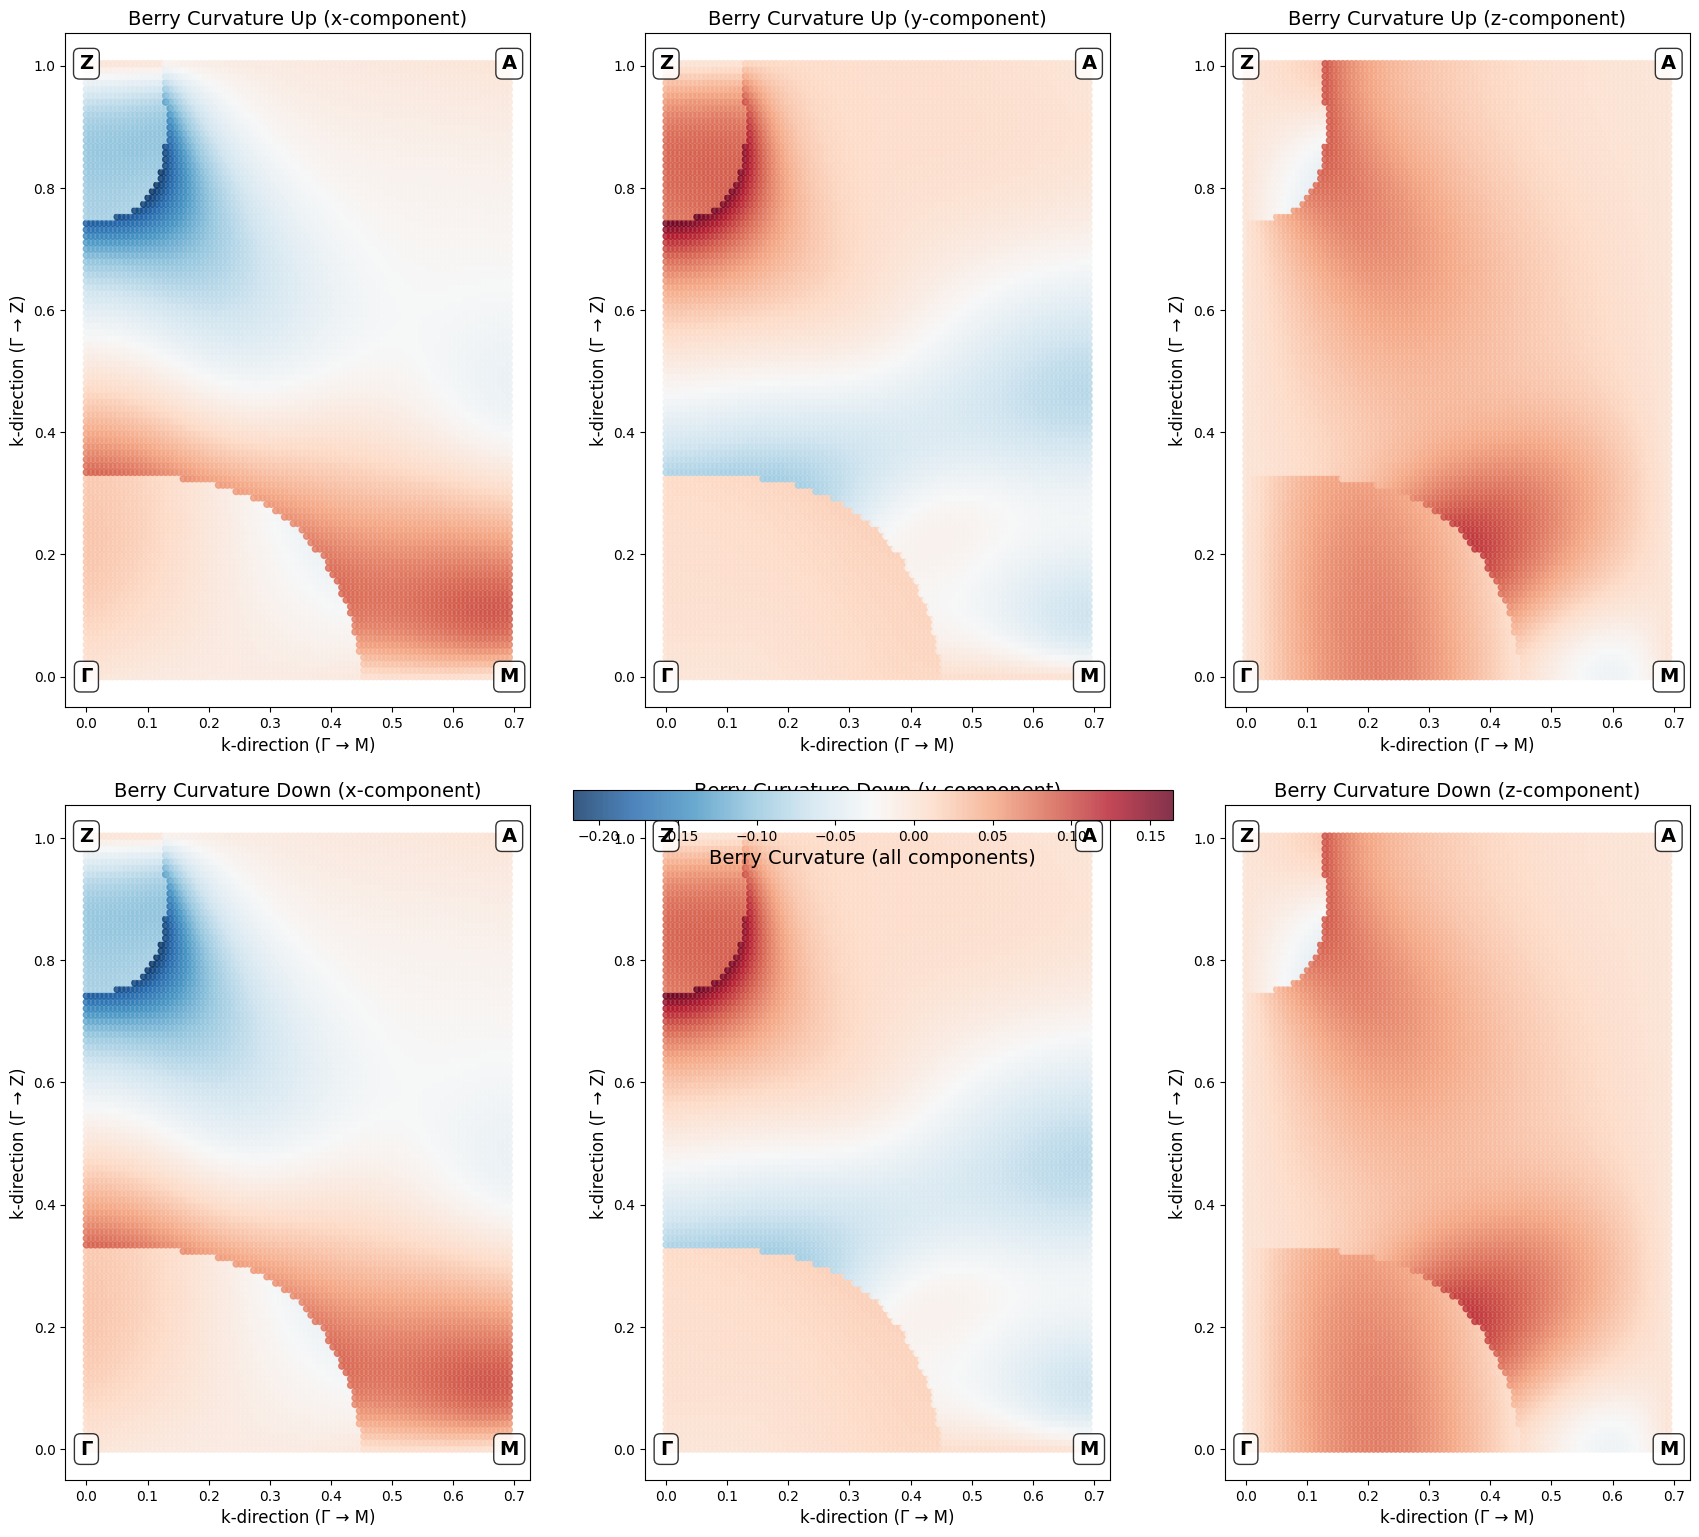

In [ ]:
# Create figure with subplots for all three Berry curvature components
fig, axes = plt.subplots(2, 3, figsize=(18, 15))

# Component names
components = ['x', 'y', 'z']

# Calculate global color range for ALL components (shared across x, y, z)
vmin_global = min(np.min(zup[0]), np.min(zup[1]), np.min(zup[2]), 
                  np.min(zdown[0]), np.min(zdown[1]), np.min(zdown[2]))
vmax_global = max(np.max(zup[0]), np.max(zup[1]), np.max(zup[2]), 
                  np.max(zdown[0]), np.max(zdown[1]), np.max(zdown[2]))

print(f'Global color range: min={vmin_global:.4f}, max={vmax_global:.4f}')

# Store scatter plot for colorbar reference
scatter_ref = None

for i, comp_name in enumerate(components):
    # Print individual component ranges for reference
    vmin_comp = min(np.min(zup[i]), np.min(zdown[i]))
    vmax_comp = max(np.max(zup[i]), np.max(zdown[i]))
    print(f'{comp_name}-component range: min={vmin_comp:.4f}, max={vmax_comp:.4f}')
    
    # Plot for up component (top row) - using global color scale
    scatter_up = axes[0, i].scatter(x, y, c=zup[i], cmap='RdBu_r', s=20, alpha=0.8, 
                                    vmin=vmin_global, vmax=vmax_global)
    axes[0, i].set_xlabel('k-direction (Γ → M)', fontsize=12)
    axes[0, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[0, i].set_title(f'Berry Curvature Up ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[0, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.min(), 'M', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[0, i].text(x.max(), y.max(), 'A', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[0, i].tick_params(labelsize=10)
    axes[0, i].set_aspect('equal')

    # Plot for down component (bottom row) - using global color scale
    scatter_down = axes[1, i].scatter(x, y, c=zdown[i], cmap='RdBu_r', s=20, alpha=0.8,
                                      vmin=vmin_global, vmax=vmax_global)
    axes[1, i].set_xlabel('k-direction (Γ → M)', fontsize=12)
    axes[1, i].set_ylabel('k-direction (Γ → Z)', fontsize=12)
    axes[1, i].set_title(f'Berry Curvature Down ({comp_name}-component)', fontsize=14)
    
    if x_range > 0.3 and y_range > 0.3:
        axes[1, i].text(x.min(), y.min(), 'Γ', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.min(), 'X', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.min(), y.max(), 'Z', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        axes[1, i].text(x.max(), y.max(), 'A', fontsize=14, fontweight='bold',
                       ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    axes[1, i].tick_params(labelsize=10)
    axes[1, i].set_aspect('equal')
    
    # Store reference for shared colorbar
    if scatter_ref is None:
        scatter_ref = scatter_up

# Add single shared horizontal colorbar below all subplots
cbar = fig.colorbar(scatter_ref, ax=axes, orientation='horizontal', fraction=0.04, pad=0.08)
cbar.ax.set_position([0.25, 0.45, 0.5, 0.02])  # [left, bottom, width, height] in figure coordinates
cbar.set_label('Berry Curvature (all components)', fontsize=14)

plt.tight_layout()
plt.show()